In [4]:
import numpy as np
import pandas as pd
import itertools
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon

In [5]:
def load_results(path):
    df = pd.read_csv(path)

    df = df.loc[:, ~df.columns.str.contains("^Unnamed")]

    for col in df.columns:
        if col.endswith("_all"):
            df[col] = (
                df[col]
                .str.replace('[', '')
                .str.replace(']', '')
                .apply(lambda x: [float(v) for v in x.split()])
            )
    return df

def to_long(df, representation, metric="F1_macro"):
    rows = []

    for _, row in df.iterrows():
        model = row["Model"]
        scores = row[f"CV_{metric}_all"]

        for s in scores:
            rows.append({
                "Representation": representation,
                "Model": model,
                metric: s
            })

    return pd.DataFrame(rows)

def compare_representations(melhores_dict, metric="MAE"):
    reps = list(melhores_dict.keys())
    pares = list(itertools.combinations(reps, 2))

    resultados = []

    for rA, rB in pares:
        linha_A = melhores_dict[rA]
        linha_B = melhores_dict[rB]

        scores_A = linha_A[f"CV_{metric}_all"]
        scores_B = linha_B[f"CV_{metric}_all"]

        stat, p = wilcoxon(scores_A, scores_B)

        media_A = np.mean(scores_A)
        media_B = np.mean(scores_B)

        if p < 0.05:
            melhor = rA if media_A < media_B else rB
        else:
            melhor = "EMPATE"

        resultados.append({
            "Rep_A": rA,
            "Rep_B": rB,
            "mean_A": media_A,
            "mean_B": media_B,
            "p": float(p),
            "Melhor": melhor
        })

    return pd.DataFrame(resultados)

## TweetEmotionsPTBR

In [6]:
paths = {
    "BoW": "../../data/out/baseline/baseline_03_TweetEmotionsPTBR_BoW.csv",
    "TFIDF": "../../data/out/baseline/baseline_03_TweetEmotionsPTBR_TFIDF.csv",
}

df_bow = load_results(paths["BoW"])
df_tfidf = load_results(paths["TFIDF"])

df_long = pd.concat([
    to_long(df_bow, "BoW"),
    to_long(df_tfidf, "TFIDF")
], ignore_index=True)

df_pair = (
    df_long
    .groupby(["Representation"])
    .head(df_long.groupby("Representation").size().min())
    .reset_index(drop=True)
)

scores_bow = df_pair[df_pair["Representation"] == "BoW"]["F1_macro"].to_numpy()
scores_tfidf = df_pair[df_pair["Representation"] == "TFIDF"]["F1_macro"].to_numpy()

stat, p = wilcoxon(scores_bow, scores_tfidf)

print(f"Wilcoxon stat = {stat:.4f}")
print(f"p-value = {p:.6f}")

diff = scores_tfidf - scores_bow
r = np.abs(stat) / np.sqrt(len(diff))
print(f"Effect size (r) = {r:.4f}")

Wilcoxon stat = 4205.0000
p-value = 0.006245
Effect size (r) = 343.3368


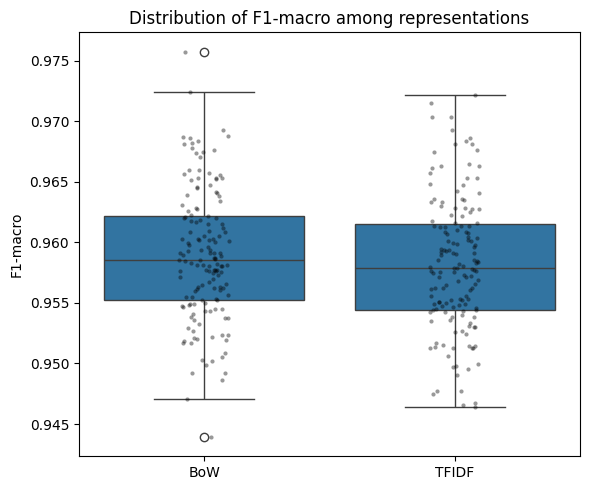

In [9]:
plt.figure(figsize=(6, 5))

sns.boxplot(
    data=df_long,
    x="Representation",
    y="F1_macro"
)

sns.stripplot(
    data=df_long,
    x="Representation",
    y="F1_macro",
    color="black",
    alpha=0.4,
    size=3
)

plt.title("Distribution of F1-macro among representations")
plt.ylabel("F1-macro")
plt.xlabel("")
plt.tight_layout()
plt.show()